### Predict Home Pricing Using Linear Regression

In this file I am trying first to build a **simple linear regression model** for predicting the home price based on the area. Basically, we are going to work with just two variables (price and area of the house) because this is a simple linear regression model.

In [1]:
# Import Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [14]:
# import DataSet
df_house_dataset = pd.read_csv("./Housing.csv")

df_house_dataset
df_h_a = pd.concat([df_house_dataset["area"], df_house_dataset["price"]], axis=1)
df_h_a

,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000
...,...,...
540,3000,1820000
541,2400,1767150
542,3620,1750000
543,2910,1750000


Text(0.5, 1.0, 'Distribution of Price and Area')

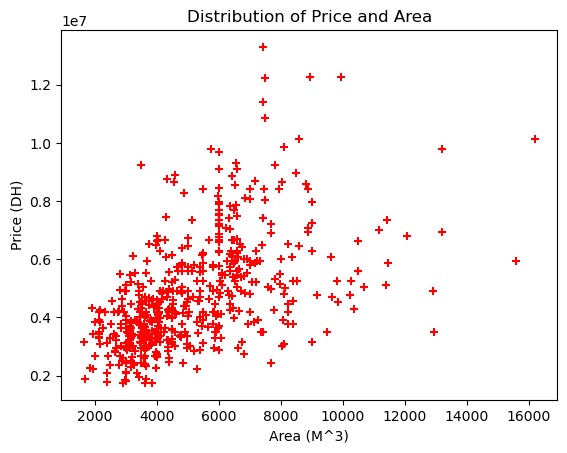

In [23]:
# Get Distrubition
plt.scatter(x=df_h_a["area"], y=df_h_a["price"], color="red", marker="+")
plt.xlabel("Area (M^3)")
plt.ylabel("Price (DH)")
plt.title("Distribution of Price and Area")

simple linear regression with simple forumla: Y = a.X + b
where Y is Price and X is Area
and The Goal is to find a and b.

In [ ]:
# Build Simple LInear Regression Model
reg = linear_model.LinearRegression()
reg.fit(df_h_a[["area"]], df_h_a.price)

In [ ]:
# Predict The House Price
reg.predict([[3000]])

# Get Coeficcient a and b
reg.coef_ # this is a
reg.intercept_ # this is b

know we try to predict the prices based on areas that exit in our csv file. <Housing.csv>

In [73]:
# Let's Predicat All Prices
areas = pd.DataFrame(df_h_a["area"])
prices_pred = reg.predict(areas)

# If We Look at House That Has Price 13300000 and Area = 7420 But Our Model Give us just 5815162.19
# Wich Means There is Some Errors Here !!!

KNow we Want make DataFramce Contains Real Price, Preciated Price and Area

In [81]:
df_predict_price = pd.DataFrame(prices_pred, columns=["predicated_price"])

final_df = pd.concat([df_h_a["area"], df_h_a["price"], df_predict_price], axis=1)
final_df

,area,price,predicated_price
0,7420,13300000,5.815162e+06
1,8960,12250000,6.526604e+06
2,9960,12250000,6.988578e+06
3,7500,12215000,5.852120e+06
4,7420,11410000,5.815162e+06
...,...,...,...
540,3000,1820000,3.773233e+06
541,2400,1767150,3.496048e+06
542,3620,1750000,4.059658e+06
543,2910,1750000,3.731655e+06


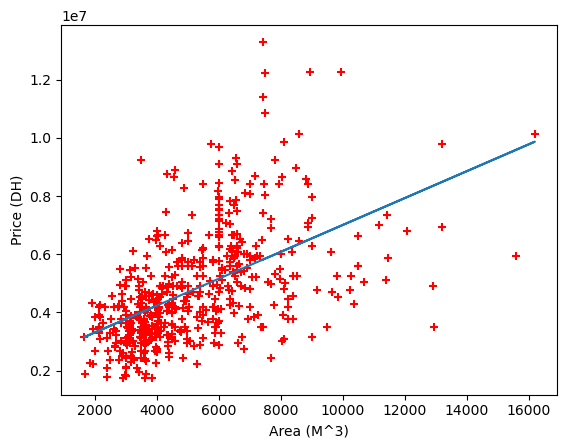

In [87]:
# Draw Line Ajustement
plt.scatter(x=df_h_a["area"], y=df_h_a["price"], color="red", marker="+")
plt.xlabel("Area (M^3)")
plt.ylabel("Price (DH)")
plt.plot(final_df.area, reg.predict(final_df[['area']]))

know let's calculate the metrics Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE)

**Mean Absolute Error (MAE):** is a statistical measure that evaluates the accuracy of a predictive or forecasting model by calculating the average of the absolute differences between predicted and actual values.

The formula is:

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

**Root Mean Squared Error (RMSE):**  
measures the average difference between a model’s predicted values and the actual values.

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

FROM: https://statisticsbyjim.com/regression/root-mean-square-error-rmse/

In [94]:
# Import Package
from sklearn.metrics import mean_absolute_error as mae, root_mean_squared_error as rmse

# Calculate the MAE:
print(f"the mean absolute error: {mae(final_df["price"], final_df["predicated_price"])}")

# Calculate the RMSE:
print(f"the root mean squared error: {rmse(final_df["price"], final_df["predicated_price"])}")

the mean absolute error: 1172305.5113148908
the root mean squared error: 1577612.5627607866


#### WHAT IS THE NEXT ?

The goal is to measure the performance of our model, not just calculate the errors and stop. 
and The next step is to try to reduce these errors.